# Dimensionless diaphragm chain

A row of bistable diaphragms (each can sit in a "low" or "high" state) connected by
sealed gas pockets. Squeezing one pocket pushes on its neighbour through Boyle's law
(pressure x volume = constant), so a switch can travel along the row as a wave.

Written in dimensionless form, the whole model depends on just **four** numbers:

| group | what it is |
|-------|------------|
| $\eta = \frac{A p_0}{k a^3}$   | gas pressure vs. how stiff each diaphragm is |
| $\theta = \frac{A a}{V_0}$ | how much a gas pocket's volume changes when a diaphragm switches |
| $\Pi = \frac{\delta}{a^3}$    | how lopsided the two states are - this is what drives the wave |
| $\Omega = \frac{\alpha}{a\sqrt{mk}}$ | damping |

The dimensional notebook already mapped what the raw knobs ($A, \delta, \alpha$) do one
at a time. This notebook is about the things you can only see with the dimensionless groups:

- **same groups means same wave** - two builds with completely different raw numbers behave identically
- **a validity map for the wave-speed formula** - the 10% bounds asked once, in group form, for every build
- **where the wave stops moving at all** - weak coupling narrows the front until the lattice
  traps it, a threshold the continuum description cannot produce
- **the fluid fingerprint** - Boyle's law is lopsided where a linear spring is not, and it
  shows: mirrored waves separate by a margin that grows without saturating, which no spring
  chain can produce, and the sweep ends with the stretching wave pinned

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
from IPython.display import display, Markdown

# House figure style: Wong palette matching the Figure 1 schematic, fonts in the
# points they reach the page at, and one save() that writes into figures/.
sys.path.insert(0, 'src')
from plotstyle import use, C, save, width, full, half, two_panel, label_line, spacetime
use()

# the four dimensionless groups (canonical values)
eta   = 80.0    # gas pressure / diaphragm stiffness
theta = 0.1     # volume change per switch
Pi    = 0.115   # asymmetry between the two states (drives the wave)
Omega = 10.0    # damping

# cached sweep results: load from CSV when present, or set True to recompute
CSV_DIR     = 'results'
FORCE_RERUN = False


In [2]:
def wells(Pi):
    """The three rest states: roots of  u^3 - u + Pi = 0,  sorted low < mid < high."""
    r = np.sort(np.roots([1, 0, -1, Pi]).real)
    return r[0], r[1], r[2]

def gas_force(u, eta, theta):
    """Boyle-law pressure force on each diaphragm."""
    p = 1.0 / (1.0 + theta * (u[1:] - u[:-1]))     # 1 / volume of each gas pocket
    F = np.zeros_like(u)
    F[1:-1] = eta * (p[:-1] - p[1:])
    return F

def energy(u, v, eta, theta, Pi):
    """Total energy: motion + the double-well + the gas."""
    gaps = 1.0 + theta * (u[1:] - u[:-1])
    well = u**4/4 - u**2/2 + Pi*u
    return 0.5*np.sum(v**2) + np.sum(well) - (eta/theta)*np.sum(np.log(gaps))

def front_speed(frames, times, u_lo, u_hi, flip=False):
    """Track where the wave front is in each frame and fit its speed."""
    N = frames.shape[1]
    mid = 0.5*(u_lo + u_hi)
    pos = []
    for f in frames:
        sel = np.where(f < mid)[0] if not flip else np.where(f > mid)[0]
        if len(sel) == 0:
            pos.append(0.0)
        elif sel[-1] + 1 >= N:
            pos.append(float(sel[-1]))
        else:
            i = sel[-1]
            pos.append(i + (f[i] - mid) / (f[i] - f[i+1]))   # sub-diaphragm crossing
    pos = np.array(pos)
    half = times > 0.5*times[-1]                             # steady half only
    return (np.polyfit(times[half], pos[half], 1)[0] if half.sum() > 2 else np.nan), pos

def grad4(u):
    """du/dn by a 4th-order central difference, unit spacing.

    np.gradient is 2nd order, and on a front only a few sites wide its truncation
    error is large: for a tanh of width w it underestimates the gradient integral
    by 2.8% at w=3 and 19% at w=1, falling off as 1/w^2. Since the energy-balance
    formula divides by that integral, the 2nd-order estimate makes the formula look
    like it degrades on narrow fronts when it is the measurement that is degrading.
    4th order removes essentially all of it above w = 2.
    """
    g = np.zeros_like(u)
    g[2:-2] = (-u[4:] + 8*u[3:-1] - 8*u[1:-3] + u[:-4]) / 12.0
    g[1], g[-2] = (u[2]-u[0])/2, (u[-1]-u[-3])/2      # 2nd order at the edges
    return g

def gradient_integral(u):
    """I = int (dU/dxi)^2 dxi, estimated from a lattice snapshot."""
    return float(np.sum(grad4(u)**2))

def run(eta, theta, Pi, Omega, N=120, T=150.0, dt=None,
        n_sponge=10, sponge=4.0, n_trigger=5, save_every=200,
        track_energy=False, flip=False, u_init=None):
    """
    Integrate the chain and return the wave.

    Normally the left end is held low and the rest starts high; the boundary travels
    right as a wave. With flip=True the roles swap (left end high, rest low), which
    runs the mirrored wave. u_init replaces the default sharp-step start with a given
    displacement field, which is what the initial-condition test below needs; the
    boundary sites are re-imposed on top of whatever it supplies. Returns a dict with
    frames, times, wave position and speed, or {'error': ...} if a gas pocket collapses.
    """
    if dt is None:
        dt = 0.05 / max(np.sqrt(2 + 4*abs(eta*theta)), Omega)
    u_lo, _, u_hi = wells(Pi)
    bg, trig = (u_hi, u_lo) if not flip else (u_lo, u_hi)

    # a little extra damping near the walls so the wave is absorbed, not reflected
    damp = np.full(N, float(Omega))
    if n_sponge > 0:
        ramp = sponge * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, bg) if u_init is None else np.asarray(u_init, dtype=float).copy()
    u[:n_trigger] = trig; u[-1] = bg
    v = np.zeros(N)
    force = lambda uu: gas_force(uu, eta, theta) - (uu**3 - uu + Pi)

    steps = int(T / dt)
    frames, E = [], []
    a = force(u) - damp*v
    for step in range(steps):
        u += v*dt + 0.5*a*dt**2
        u[:n_trigger] = trig; u[-1] = bg
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        if step > steps//10 and np.min(1 + theta*(u[1:]-u[:-1])) <= 0:
            return {'error': 'a gas pocket collapsed to zero volume'}
        f = force(u)
        v = (v + 0.5*dt*(a + f)) / (1 + 0.5*damp*dt)   # semi-implicit, handles damping
        v[:n_trigger] = 0.0; v[-1] = 0.0
        a = f - damp*v
        if step % save_every == 0:
            frames.append(u.copy())
            if track_energy: E.append(energy(u, v, eta, theta, Pi))

    frames = np.array(frames)
    times  = np.arange(len(frames)) * save_every * dt
    speed, pos = front_speed(frames, times, u_lo, u_hi, flip=flip)

    out = {'frames': frames, 'times': times, 'pos': pos, 'speed': speed,
           'u_lo': u_lo, 'u_hi': u_hi, 'dt': dt}
    if track_energy: out['energy'] = np.array(E)
    return out

# src/dimless.py holds the same simulator so the sweep scripts can import it.
# Keep the two in step; scripts/closed_form_check.py checks that they agree.

## A travelling wave

Hold the left end low and the right end high. The boundary between them moves along
the chain as a switching wave. Below it is shown at four moments in time. This is simply verifying what was shown in the dimensional notebook already.

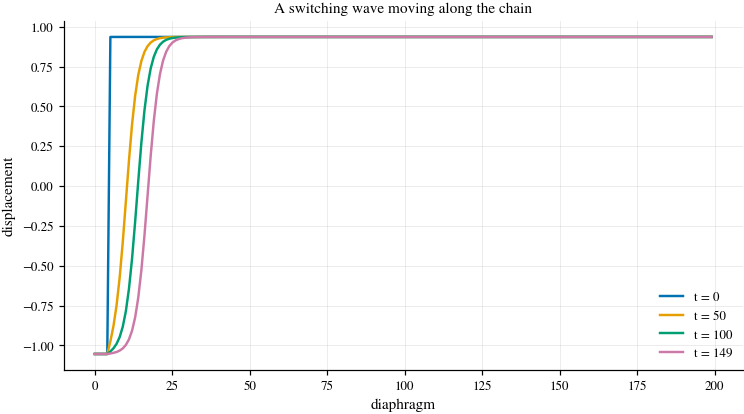

wave speed: 0.069 diaphragms per unit time


In [3]:
r = run(eta, theta, Pi, Omega, N=200, T=150)
sites = np.arange(r['frames'].shape[1])

plt.figure(figsize=(7, 4))
idx = [0, len(r['frames'])//3, 2*len(r['frames'])//3, len(r['frames'])-1]
for i in idx:
    plt.plot(sites, r['frames'][i], label=f"t = {r['times'][i]:.0f}")
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('A switching wave moving along the chain')
plt.legend(); plt.tight_layout(); plt.show()

print(f"wave speed: {r['speed']:.3f} diaphragms per unit time")

## Same groups, same wave

Build two completely different physical systems - different masses, stiffnesses and
pressures - but chosen to share the same four non-dimensional groups by scaling choices. They produce the
exact same wave. This is the foundation everything else rests on.

  system A:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
  system B:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
biggest difference between the three runs: 1.0e-14


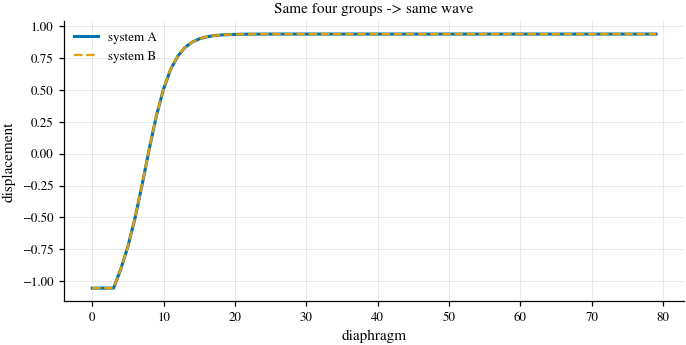

In [4]:
def dimensional_from_groups(eta, theta, Pi, Omega, m, k, a, A):
    """Physical parameters that reproduce the four groups (m, k, a, A are free choices)."""
    return dict(m=m, k=k, a=a, A=A,
                p0=eta*k*a**3/A, V0=A*a/theta, delta=Pi*a**3, alpha=Omega*a*np.sqrt(m*k))

def groups_from_dimensional(p):
    """Go the other way: recover (eta, theta, Pi, Omega) from physical parameters."""
    return (p['A']*p['p0']/(p['k']*p['a']**3), p['A']*p['a']/p['V0'],
            p['delta']/p['a']**3, p['alpha']/(p['a']*np.sqrt(p['m']*p['k'])))

def run_dimensional(m, A, k, p0, V0, a, delta, alpha,
                    N=80, T=60.0, dt_tilde=None, n_sponge=6, sponge=4.0,
                    n_trigger=4, save_every=100):
    """The same simulation in raw physical units. Returns (times, frames) with the
    output already rescaled, or None if a gas pocket collapses."""
    eta_ = A*p0/(k*a**3)
    Omega_ = alpha/(a*np.sqrt(m*k))
    if dt_tilde is None:
        dt_tilde = 0.05 / max(np.sqrt(2 + 4*abs(eta_*A*a/V0)), Omega_)
    T_scale = np.sqrt(m/(k*a**2))
    dt = dt_tilde * T_scale
    u_lo, _, u_hi = np.sort(np.roots([1, 0, -a**2, delta]).real)

    damp = np.full(N, float(alpha))
    if n_sponge > 0:
        ramp = sponge * a*np.sqrt(m*k) * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, u_hi); u[:n_trigger] = u_lo
    v = np.zeros(N)
    def force(uu):
        pr = p0*V0 / (V0 + A*(uu[1:] - uu[:-1]))
        F = np.zeros_like(uu); F[1:-1] = A*(pr[:-1] - pr[1:])
        return F - k*(uu**3 - a**2*uu + delta)

    steps = int(T*T_scale / dt)
    hist, acc = [], (force(u) - damp*v) / m
    for step in range(steps):
        u += v*dt + 0.5*acc*dt**2
        u[:n_trigger] = u_lo; u[-1] = u_hi; v[:n_trigger] = 0; v[-1] = 0
        if step > steps//10 and np.min(V0 + A*(u[1:] - u[:-1])) <= 0:
            return None                                    # pocket collapsed
        f = force(u)
        v = (v + 0.5*dt*(acc + f/m)) / (1 + 0.5*damp*dt/m)
        v[:n_trigger] = 0; v[-1] = 0
        acc = (f - damp*v) / m
        if step % save_every == 0:
            hist.append(u / a)              # divide by length scale -> same units as run()
    return np.arange(len(hist)) * save_every * dt_tilde, np.array(hist)

# two genuinely different physical builds, both tuned to the same four groups
A_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=1.0,  k=1.0,   a=1.0,  A=1.0)
B_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=3e-3, k=250.0, a=0.02, A=5e-4)

for name, p in [('system A', A_sys), ('system B', B_sys)]:
    e, t, pi, om = groups_from_dimensional(p)
    print(f"  {name}:  eta={e:.2f}   theta={t:.3f}   Pi={pi:.4f}   Omega={om:.3f}")

# run both physical systems and the dimensionless one; they should coincide
dt0 = 0.05 / max(np.sqrt(2 + 4*eta*theta), Omega)
kw  = dict(N=80, T=60.0, dt_tilde=dt0, n_sponge=6, n_trigger=4, save_every=100)
tA, hA = run_dimensional(**A_sys, **kw)
tB, hB = run_dimensional(**B_sys, **kw)
hD = run(eta, theta, Pi, Omega, N=80, T=60.0, dt=dt0,
         n_sponge=6, n_trigger=4, save_every=100)['frames']

n    = min(len(hA), len(hB), len(hD))
diff = max(np.max(np.abs(hA[:n]-hB[:n])), np.max(np.abs(hA[:n]-hD[:n])))
print(f"biggest difference between the three runs: {diff:.1e}")

# Two overlaid curves look identical whether they agree to 1e-14 or to 1e-4, so the
# claim needs its own panel. Sites where the difference is exactly zero would vanish
# on a log axis, so floor them at 1e-18 (well below anything meaningful here).
mid = n // 2

fig, ax = plt.subplots(figsize=full(3.2))
ax.plot(hA[mid], '-',  color=C.data,   lw=2,   label='system A')
ax.plot(hB[mid], '--', color=C.theory, lw=1.5, label='system B')
ax.set_xlabel('diaphragm'); ax.set_ylabel('displacement')
ax.set_title('Same four groups -> same wave')
ax.legend(); ax.grid(True, alpha=0.3)
save(fig, 'dimensionless_verification')
plt.show()

## Check: the simulation is sound

Turn the damping off ($\Omega = 0$). With no damping the total energy should stay flat -
a basic check that the integrator is behaving and not quietly adding or losing energy.

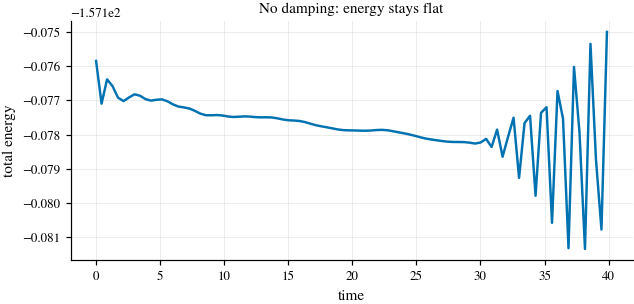

largest energy drift: 3.5e-05


In [5]:
r0 = run(eta, theta, Pi, 0.0, N=80, T=40, n_sponge=0, n_trigger=4,
         save_every=50, track_energy=True)
E = r0['energy']
drift = np.max(np.abs((E - E[0]) / abs(E[0])))

plt.figure(figsize=(6, 3))
plt.plot(r0['times'][:len(E)], E)
plt.xlabel('time'); plt.ylabel('total energy')
plt.title('No damping: energy stays flat'); plt.tight_layout(); plt.show()

print(f"largest energy drift: {drift:.1e}")

## Convergence of the discretisation

Two checks on the numerics rather than on the physics: that the timestep is small
enough, and that the lattice is long enough, for neither to be influencing the
answer.

They are run in the **dimensional** variables of `diaphragm_metafluid.ipynb`
($A = 1$, $\delta = 0.001$, $\alpha = 0.10$), which is deliberate. Convergence is a
property of the integrator, not of the four groups, and this is the operating
point where the reproducible result of `uq_reproducible_result.ipynb` is quoted -
so both of that result's error bars refer to the same place. Each cell caches to
`results/`, so they load in seconds after the first run.

        dt    Cauchy error   error ratio  note
----------------------------------------------------------
   8.0e-04      6.7629e-09            --
   4.0e-04      1.6956e-09          3.99
   2.0e-04      4.2516e-10          3.99
   1.0e-04      8.9508e-11          4.75


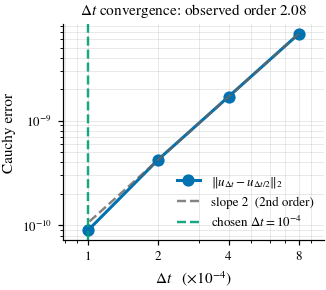

In [6]:
# ── Δt convergence: Cauchy self-convergence test ─────────────────────────────
#
# Goal: check the timestep dt is small enough that the answer no longer depends on it.
#
# Normally you'd measure the error as |numerical − exact|. But this nonlinear lattice
# has no closed-form solution, so there is no exact answer to compare against.
#
# So we use the Cauchy idea instead: a sequence converges if its terms get arbitrarily
# close to each other — you don't need to know the limit. Here the sequence is the
# solution as we keep halving the timestep — u(dt), u(dt/2), u(dt/4), ... — and we measure
# the gap between successive refinements, |u(dt) − u(dt/2)|. If that gap shrinks toward
# zero, the scheme is converging.
#
# The rate of shrinkage also reveals the order of accuracy: for a p-th order method the
# gap scales as dt^p, so halving dt divides it by 2^p. Velocity Verlet is 2nd order
# (p=2), so the gap should drop by 4 each time — a straight line of slope 2 on log-log.
#
# Caveat: a shrinking gap only proves convergence to some limit. That the limit is the
# true solution follows because velocity Verlet is a standard, provably-consistent scheme.
# Consistency (from theory) + self-convergence (measured here) = confidence in dt.

def _evolve_dt(dt_run, T_run=40.0, N_cv=120, A=1.0, delta=0.001, alpha=0.10,
               n_sponge=10, damp_max=4.0, n_trigger=5):
    a2 = 0.09; m = 1.0; p0 = 1.0; v0 = 1.0
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    _u_lo, _, _u_hi = real_roots

    _damp = np.ones(N_cv) * alpha
    for i in range(n_sponge):
        s = damp_max * ((n_sponge - i) / n_sponge) ** 2
        _damp[i] += s;  _damp[N_cv - 1 - i] += s

    def _net(u):
        F  = np.zeros_like(u)
        sv = v0 + A * (u[1:] - u[:-1])
        F[1:-1] = A * (p0*v0/sv[:-1] - p0*v0/sv[1:])
        return F - (u**3 - a2*u + delta)

    u = np.ones(N_cv) * _u_hi;  u[:n_trigger] = _u_lo
    v = np.zeros(N_cv)
    F0 = _net(u);  a_arr = (F0 - _damp*v) / m
    for _ in range(int(round(T_run / dt_run))):
        u += v*dt_run + 0.5*a_arr*dt_run**2
        u[:n_trigger] = _u_lo;  u[-1] = _u_hi
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        F_new = _net(u)
        v     = (v + 0.5*dt_run*(a_arr + F_new/m)) / (1.0 + 0.5*_damp*dt_run/m)
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        a_arr = (F_new - _damp*v) / m
    return u

# Cached like every other expensive sweep here: five runs down to dt=5e-5 cost a
# few minutes, and nothing about the plot needs them repeated.
CSV_DTC = os.path.join(CSV_DIR, 'dt_convergence.csv')
if not FORCE_RERUN and os.path.exists(CSV_DTC):
    _d    = pd.read_csv(CSV_DTC)
    dt_err, errs = _d.dt.values, _d.cauchy_error.values
else:
    dts  = np.array([8e-4, 4e-4, 2e-4, 1e-4, 5e-5])
    sols = [_evolve_dt(d) for d in dts]
    errs = np.array([np.linalg.norm(sols[i] - sols[i+1]) for i in range(len(dts)-1)])
    dt_err = dts[:-1]
    pd.DataFrame(dict(dt=dt_err, cauchy_error=errs)).to_csv(CSV_DTC, index=False)
    print(f"Saved -> {CSV_DTC}")
ratios = errs[:-1] / errs[1:]   # should be ~4 for 2nd order; drops when converged

print(f"{'dt':>10}  {'Cauchy error':>14}  {'error ratio':>12}  note")
print("-" * 58)
for i, (dt_run, err) in enumerate(zip(dt_err, errs)):
    rat = f"{ratios[i-1]:.2f}" if i > 0 else "   --"
    print(f"{dt_run:10.1e}  {err:14.4e}  {rat:>12}")

mean_order = np.mean(np.log2(ratios))

fig, ax = plt.subplots(figsize=half(2.7))
ax.loglog(dt_err, errs, "o-", color=C.data, linewidth=2, markersize=7,
          label=r"$\|u_{\Delta t} - u_{\Delta t/2}\|_2$")
ref2 = errs[0] / dt_err[0]**2 * dt_err**2
ax.loglog(dt_err, ref2, "--", color=C.ref, alpha=0.8, label="slope 2  (2nd order)")
ax.axvline(1e-4, color=C.third, linestyle="--", alpha=0.9,
           label=r"chosen $\Delta t = 10^{-4}$")

# at this figure width matplotlib's default log minor labels (2x10^-4, 3x10^-4, ...)
# run into each other, so tick only at the four dt actually used
from matplotlib.ticker import NullFormatter
ax.set_xticks(dt_err)
ax.set_xticklabels([f"{d/1e-4:g}" for d in dt_err])
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlim(dt_err.min()*0.78, dt_err.max()*1.28)
ax.set_xlabel(r"$\Delta t$   ($\times 10^{-4}$)")
ax.set_ylabel("Cauchy error")
ax.set_title(rf"$\Delta t$ convergence: observed order {mean_order:.2f}")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
save(fig, 'dt_convergence')

plt.show()


     N     v_sim
--------------------------
    50  0.2227
   100  0.2206
   120  0.2206
   150  0.2206
   200  0.2206
   300  0.2206


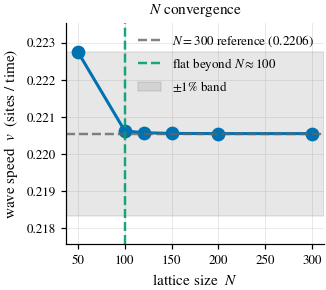

In [7]:
# ── N convergence: wave speed vs lattice size ─────────────────────────────────
# Verify that the chosen N is large enough that v_sim is independent of N.
# Too small an N and the wave has insufficient room to reach a clean steady state
# before hitting the sponge layer.
#
# T is scaled proportionally to N so the wave traverses the same fraction of
# the lattice in each run — this prevents sponge bias from varying with N.

def _v_for_N(N_run, T_run, A=1.0, delta=0.001, alpha=0.10, dt=1e-4,
             n_sponge=10, damp_max=4.0, n_trigger=5, save_every=500):
    a2 = 0.09; m = 1.0; p0 = 1.0; v0 = 1.0
    roots = np.roots([1, 0, -a2, delta])
    real_roots = sorted(roots[np.abs(roots.imag) < 1e-10].real)
    _u_lo, _, _u_hi = real_roots

    _damp = np.ones(N_run) * alpha
    for i in range(n_sponge):
        s = damp_max * ((n_sponge - i) / n_sponge) ** 2
        _damp[i] += s;  _damp[N_run - 1 - i] += s

    def _net(u):
        F  = np.zeros_like(u)
        sv = v0 + A * (u[1:] - u[:-1])
        F[1:-1] = A * (p0*v0/sv[:-1] - p0*v0/sv[1:])
        return F - (u**3 - a2*u + delta)

    u = np.ones(N_run) * _u_hi;  u[:n_trigger] = _u_lo
    v = np.zeros(N_run)
    F0 = _net(u);  a_arr = (F0 - _damp*v) / m
    hist = []
    for step in range(int(T_run / dt)):
        u += v*dt + 0.5*a_arr*dt**2
        u[:n_trigger] = _u_lo;  u[-1] = _u_hi
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        Fn    = _net(u)
        v     = (v + 0.5*dt*(a_arr + Fn/m)) / (1.0 + 0.5*_damp*dt/m)
        v[:n_trigger] = 0.0;    v[-1] = 0.0
        a_arr = (Fn - _damp*v) / m
        if step % save_every == 0:
            hist.append(u.copy())

    hist  = np.array(hist)
    _mid  = 0.5 * (_u_lo + _u_hi)
    times = np.arange(len(hist)) * save_every * dt
    fp    = []
    for s in hist:
        below = np.where(s < _mid)[0]
        if len(below) == 0:
            fp.append(0.0)
        elif below[-1] + 1 >= len(s):
            fp.append(float(below[-1]))
        else:
            n = below[-1]
            fp.append(n + (_mid - s[n]) / (s[n+1] - s[n]))
    fp     = np.array(fp, dtype=float)
    steady = times > 0.2 * T_run
    if steady.sum() < 5:
        return np.nan
    spd, _ = np.polyfit(times[steady], fp[steady], 1)
    return spd

# T = 2xN keeps the wave in the bulk throughout (at v~0.22 sites/time the front
# travels ~0.44*N sites in T=2*N, well short of the sponge at N-10).
N_T_pairs = [(50, 100), (100, 200), (120, 240), (150, 300), (200, 400), (300, 600)]

CSV_NC = os.path.join(CSV_DIR, 'N_convergence.csv')
if not FORCE_RERUN and os.path.exists(CSV_NC):
    _n = pd.read_csv(CSV_NC)
    N_vals_plot, v_N = list(_n.N), list(_n.v_sim)
else:
    v_N = []
    for N_run, T_run in N_T_pairs:
        v_N.append(_v_for_N(N_run, T_run))
    N_vals_plot = [p[0] for p in N_T_pairs]
    pd.DataFrame(dict(N=N_vals_plot, T=[p[1] for p in N_T_pairs],
                      v_sim=v_N)).to_csv(CSV_NC, index=False)
    print(f"Saved -> {CSV_NC}")

print(f"{'N':>6}  {'v_sim':>8}")
print("-" * 26)
for _Nv, _vv in zip(N_vals_plot, v_N):
    print(f"{_Nv:6d}  {_vv:.4f}")
v_ref = v_N[-1]   # N=300 as reference

fig, ax = plt.subplots(figsize=half(2.7))
ax.plot(N_vals_plot, v_N, 'o-', color=C.data, markersize=8, linewidth=2)
ax.axhline(v_ref, color=C.ref, linestyle='--', alpha=0.8,
           label=rf'$N=300$ reference ({v_ref:.4f})')
ax.axvline(100, color=C.third, linestyle='--', alpha=0.9,
           label=r'flat beyond $N \approx 100$')
ax.axhspan(v_ref * 0.99, v_ref * 1.01, alpha=0.15, color=C.band, label=r'$\pm$1% band')
# widen slightly past the band, or a band that covers every point reads as a
# grey page background rather than as a tolerance
ax.set_ylim(v_ref * 0.9865, v_ref * 1.0135)
ax.set_xlabel('lattice size  $N$')
ax.set_ylabel(r'wave speed  $v$  (sites / time)')
ax.set_title(r'$N$ convergence')
ax.legend();  ax.grid(True, alpha=0.3)
save(fig, 'N_convergence')

plt.show()

### Reached from either side

The energy-balance argument does not merely assert that $v^\ast$ is where supply and
dissipation happen to match — it claims $v^\ast$ is a *stable fixed point*, since supply
grows like $v$ while dissipation grows like $v^2$, so a slow front accelerates and a fast
one decelerates. Every run so far starts from the same sharp step, which puts that claim to
no test at all. Starting three fronts of deliberately wrong width, at the same site under
the same parameters, does.

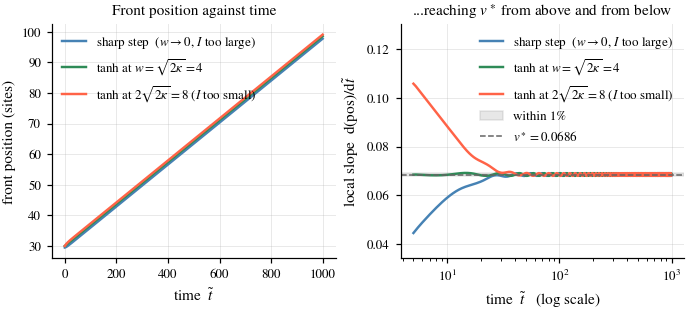

  starts at 0.0446   settles at 0.068571
  starts at 0.0685   settles at 0.068571
  starts at 0.1058   settles at 0.068570
  spread across the three: 0.0004%



**The speed is a fixed point, not an accident of how the wave was started.** Three
initial fronts of very different width, released at the same site under identical
parameters, begin at local speeds of 0.045, 0.069 and
0.106 — spanning a factor of 2.4 — and all three
settle onto $v^\ast = 0.06857$, agreeing to
**0.0004%**. The two that start away from it approach from opposite
directions, which is the signature the energy-balance argument predicts: the step, whose
$I$ is too large, is too slow and accelerates; the over-wide tanh, whose $I$ is too small,
is too fast and decelerates. A speed that merely balanced energy would keep whatever value
it was handed.


In [8]:
# ── Is v* really a fixed point, reached from either side? ────────────────────
#
# The energy-balance argument says the front does not happen to travel at v*, it is
# driven there: supply grows like v and dissipation like v^2, so a slow front speeds
# up and a fast one slows down. Every run in this notebook starts from the same sharp
# step, which tests none of that. Here three starts are given the same parameters and
# the same starting site, differing only in the width of the front they begin with,
# which is what sets I = int(U'^2) and hence the speed they begin at:
#
#   sharp step   w -> 0    I too large   starts too slow   must accelerate
#   tanh at w              I about right starts at v*      stays
#   tanh at 2w             I too small   starts too fast   must decelerate
#
# All three must end on the same speed. Note the starting site matters: the default
# sharp step sits on top of the pinned trigger sites, whose boundary work makes the
# early front position move for reasons that are not propagation, so all three are
# started at n_0 = 30 instead, well clear of it.

N_B, T_B, SAV_B, N0_B = 200, 1000.0, 50, 30.0
w_B = np.sqrt(2*eta*theta)
_lo, _, _hi = wells(Pi)
_n = np.arange(N_B, dtype=float)
_tanh_ic = lambda width: 0.5*(_lo + _hi) + 0.5*(_hi - _lo)*np.tanh((_n - N0_B)/width)

ICS = [(r'sharp step  ($w\to0$, $I$ too large)', np.where(_n < N0_B, _lo, _hi), 'steelblue'),
       (rf'tanh at $w=\sqrt{{2\kappa}}={w_B:.0f}$', _tanh_ic(w_B), 'seagreen'),
       (rf'tanh at $2\sqrt{{2\kappa}}={2*w_B:.0f}$ ($I$ too small)', _tanh_ic(2*w_B), 'tomato')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=two_panel())
speeds_B, starts_B = [], []
for lab, u0, col in ICS:
    r = run(eta, theta, Pi, Omega, N=N_B, T=T_B, save_every=SAV_B, u_init=u0)
    t, pos = r['times'], r['pos']
    speeds_B.append(r['speed'])
    ax1.plot(t, pos, '-', color=col, lw=1.6, label=lab)

    # the approach is invisible in position; take the local slope on a sliding window
    win = 40
    loc = np.array([np.polyfit(t[i:i+win], pos[i:i+win], 1)[0] for i in range(len(t)-win)])
    ax2.plot(t[:len(loc)] + 0.5*win*(t[1]-t[0]), loc, '-', color=col, lw=1.6, label=lab)
    starts_B.append(loc[0])

v_star_B = float(np.mean(speeds_B))
spread_B = (max(speeds_B) - min(speeds_B)) / v_star_B

ax1.set_xlabel(r'time  $\tilde t$')
ax1.set_ylabel('front position (sites)')
ax1.set_title('Front position against time')
ax1.grid(True, alpha=0.3); ax1.legend(loc='upper left')

ax2.axhspan(0.99*v_star_B, 1.01*v_star_B, color=C.band, alpha=0.15, label='within 1%')
ax2.axhline(v_star_B, color=C.ref, ls='--', lw=1.0, label=rf'$v^\ast = {v_star_B:.4f}$')
ax2.set_xscale('log'); ax2.set_ylim(0.5*v_star_B, 1.9*v_star_B)
ax2.set_xlabel(r'time  $\tilde t$   (log scale)')
ax2.set_ylabel(r'local slope  $\mathrm{d}(\mathrm{pos})/\mathrm{d}\tilde t$')
ax2.set_title(r'...reaching $v^\ast$ from above and from below')
ax2.grid(True, alpha=0.3); ax2.legend(loc='upper right')

save(fig, 'ic_convergence')
plt.show()

for (lab, _, _), v0, vf in zip(ICS, starts_B, speeds_B):
    print(f"  starts at {v0:.4f}   settles at {vf:.6f}")
print(f"  spread across the three: {100*spread_B:.4f}%")

display(Markdown(f"""
**The speed is a fixed point, not an accident of how the wave was started.** Three
initial fronts of very different width, released at the same site under identical
parameters, begin at local speeds of {starts_B[0]:.3f}, {starts_B[1]:.3f} and
{starts_B[2]:.3f} — spanning a factor of {max(starts_B)/min(starts_B):.1f} — and all three
settle onto $v^\\ast = {v_star_B:.5f}$, agreeing to
**{100*spread_B:.4f}%**. The two that start away from it approach from opposite
directions, which is the signature the energy-balance argument predicts: the step, whose
$I$ is too large, is too slow and accelerates; the over-wide tanh, whose $I$ is too small,
is too fast and decelerates. A speed that merely balanced energy would keep whatever value
it was handed.
"""))

## Where does the speed formula hold, in group language?

The dimensional notebook measured, knob by knob, where the energy-balance
prediction (speed = energy released / damping x gradient integral) stays within
10% of the true speed. Those bounds were tied to the one build they were
measured on. Asking the question in groups answers it once, for every build:
sweep each group with the other three held at their canonical values, and shade
where the prediction is within 10%.

What the sweeps show, at this slice: damping is the key dial. Once the
chain is safely overdamped the formula tolerates almost everything else - drive
right up to the boundary, coupling far below its canonical value, and any $\theta$
across the range swept here. Push $\Omega$ below $\sim 0.13$ and it fails fast, and it
keeps getting worse the lower $\Omega$ goes.

That breakdown is real, not a measurement artefact. The dimensional notebook tests the
same limit head-on at low $\alpha$: sizing the lattice to the (fast) underdamped speed so
the front stays in the bulk, then measuring the ratio in successive time windows. It comes
out flat - unchanged even after the ringing has completely decayed - and grows steadily as
damping falls. The reason is that the energy-balance formula *is* the overdamped limit: it
assumes the drive energy all goes into damping, so as $\Omega \to 0$ it ignores an
ever-larger share of the physics (the front's own inertia, and the lattice waves it
radiates). Same effect in both notebooks, in different coordinates.

This also explains the dimensional notebook's $\delta$ and $A$ bounds: they were
measured at $\Omega \sim 0.33$, close to the fragile edge, where the other dials
still matter. Deep in the overdamped regime both constraints dissolve.

### What the formula assumes exists

Before asking how accurate (10) is, it is worth looking at the object it integrates over.
The formula needs a travelling profile $U(\xi)$ — a fixed shape moving at constant speed —
and in the continuum limit the model supplies one exactly: balancing the spring stiffness
$\kappa = \eta\theta$ of the gas against the double well gives a kink

$$\tilde u(\xi) = \tanh\!\left(\frac{\xi}{\sqrt{2\kappa}}\right), \qquad \xi = n - n_0,$$

of width $w = \sqrt{2\kappa}$ lattice spacings. Nothing in that prediction is free. The
comparison below fits nothing: the width comes from $\kappa$, and the centre $n_0$ from the
same midpoint interpolation used to measure every speed here. Whether the lattice has
enough diaphragms inside the switch to represent that curve is the question the rest of the
section answers in percentages.

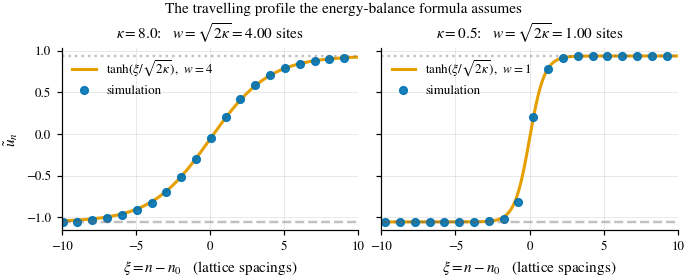

kappa=8.0    w=4.00  sites inside the switch=9  max deviation=1.1% of (u_hi-u_lo)  v=0.06871
kappa=0.5    w=1.00  sites inside the switch=2  max deviation=6.5% of (u_hi-u_lo)  v=0.01241



**The parameter-free kink, and where the lattice stops resolving it.** At the canonical
$\kappa = 8.0$ the predicted width is $w = \sqrt{2\kappa} = 4.00$
spacings, 9 diaphragms sit inside the switch, and the simulation follows the
prediction to 1.1% of the well separation with nothing fitted. At
$\kappa = 0.5$ the same formula gives $w = 1.00$, only
2 diaphragms are inside the switch, and the deviation grows to
6.5%: there is no longer a profile for the lattice to sample, which is
what the accuracy figures below measure and what pins the wave outright a little further
down in $\kappa$.


In [9]:
# ── The profile the formula assumes, against the profile the lattice has ─────
#
# Formula (10) integrates over a travelling profile U(xi). In the continuum limit
# the gas acts as a spring chain of stiffness kappa = eta*theta, and balancing that
# against the double well gives an exact kink,
#
#     u(xi) = tanh(xi / sqrt(2 kappa)),        xi = n - n_0,
#
# so the whole prediction is fixed by kappa alone. Nothing below is fitted: the
# width comes from kappa and the centre n_0 from the same midpoint interpolation
# that measures every wave speed in this notebook. Compare that against a wide
# front and a narrow one and the accuracy figures that follow stop being surprising.

CASES = [(8.0, 200, 150.0, 200),      # kappa, N, T, save_every  -- canonical, w = 4
         (0.5, 120, 3000.0, 2000)]    # narrow: w = 1, still above the pinning threshold

fig, axes = plt.subplots(1, 2, figsize=two_panel(2.6), sharey=True)
rows_A = []
for ax, (kap, N_a, T_a, sav_a) in zip(axes, CASES):
    r = run(kap/theta, theta, Pi, Omega, N=N_a, T=T_a, save_every=sav_a)
    idx  = int(0.6*len(r['frames']))          # well clear of the trigger and the sponge
    snap = r['frames'][idx]
    n0   = r['pos'][idx]                      # midpoint interpolation, as everywhere else
    w    = np.sqrt(2*kap)
    lo, hi = r['u_lo'], r['u_hi']

    xi     = np.arange(N_a) - n0
    dense  = np.linspace(-10, 10, 400)
    kink   = lambda x: 0.5*(lo + hi) + 0.5*(hi - lo)*np.tanh(x/w)
    keep   = np.abs(xi) <= 10
    band   = (snap > lo + 0.1*(hi - lo)) & (snap < hi - 0.1*(hi - lo))
    inside = int(band.sum())
    dev    = np.max(np.abs(snap[keep] - kink(xi[keep]))) / (hi - lo)

    # No highlight on the sites inside the switch. Recolouring them collided with
    # the orange prediction, and shading the band covers 80% of the axes, which
    # reads as a grey background. The count is a number, so it goes in the
    # annotation; how many markers span the ramp is already visible.
    ax.plot(dense, kink(dense), '-', color=C.theory, lw=2,
            label=rf'$\tanh(\xi/\sqrt{{2\kappa}})$,  $w={w:g}$')
    ax.plot(xi[keep], snap[keep], 'o', color=C.data, ms=5, alpha=0.9,
            label='simulation')
    ax.axhline(lo, color=C.ref, ls='--', alpha=0.4)
    ax.axhline(hi, color=C.ref, ls=':',  alpha=0.4)
    ax.set_xlim(-10, 10)
    ax.set_xlabel(r'$\xi = n - n_0$   (lattice spacings)')
    ax.set_title(rf'$\kappa = {kap}$:   $w = \sqrt{{2\kappa}} = {w:.2f}$ sites')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')
    # No annotation on the figure. The site count is in the caption, and the max
    # deviation was inviting a comparison with the speed-ratio errors of the next
    # figure, which are a different quantity measured a different way.
    rows_A.append((kap, w, inside, 100*dev, r['speed']))

axes[0].set_ylabel(r'$\tilde u_n$')
plt.suptitle('The travelling profile the energy-balance formula assumes')
save(fig, 'tanh_profile_overlay')
plt.show()

for kap, w, inside, dev, sp in rows_A:
    print(f"kappa={kap:<5}  w={w:.2f}  sites inside the switch={inside}  "
          f"max deviation={dev:.1f}% of (u_hi-u_lo)  v={sp:.5f}")

display(Markdown(f"""
**The parameter-free kink, and where the lattice stops resolving it.** At the canonical
$\\kappa = {rows_A[0][0]}$ the predicted width is $w = \\sqrt{{2\\kappa}} = {rows_A[0][1]:.2f}$
spacings, {rows_A[0][2]} diaphragms sit inside the switch, and the simulation follows the
prediction to {rows_A[0][3]:.1f}% of the well separation with nothing fitted. At
$\\kappa = {rows_A[1][0]}$ the same formula gives $w = {rows_A[1][1]:.2f}$, only
{rows_A[1][2]} diaphragms are inside the switch, and the deviation grows to
{rows_A[1][3]:.1f}%: there is no longer a profile for the lattice to sample, which is
what the accuracy figures below measure and what pins the wave outright a little further
down in $\\kappa$.
"""))

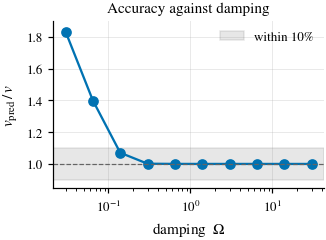

Omega:     within 10% for Omega >~ 0.13
eta*theta: within 10% for eta*theta >~ 0.79
Pi:        worst error 0.1%
theta:     worst error 0.1%


In [10]:
# One sweep per group, others at canonical (eta*theta=8, theta=0.1, Pi=0.115, Omega=10).
#
# Two things here were wrong before and are worth stating, because both made the
# formula look worse than it is:
#
#  1. The gradient integral was taken with np.gradient (2nd order). On a front a
#     few sites wide its truncation error is a percent or more and it always biases
#     I low, hence the ratio high. It is now taken with grad4 (see the simulator
#     cell), which removes essentially all of it above w = 2.
#  2. Runs were sized so the front crossed a fixed number of *sites*. The profile
#     settles only after the front has travelled several times its own *width*, so
#     wide fronts were still relaxing when the snapshot was taken. Sizing is now
#     travel = 25*w, which converges I to better than 0.01% for w >= 2.
#
# The Omega sweep keeps its original sizing: at Omega < 1 the wave crosses the
# lattice faster than the wake decays, so travel and ring-down cannot both be
# satisfied, and that regime is analysed head-on in the dimensional notebook.
# Cached: the sweeps now run a few minutes.

CSV_VAL = os.path.join(CSV_DIR, 'validity_map.csv')

def arrieta_ratio(res, Pi_v, Omega_v):
    """Predicted / measured speed; prediction from the mid-run front profile."""
    snap = res['frames'][int(0.75*(len(res['frames']) - 1))]
    integral = gradient_integral(snap)                 # 4th order, not np.gradient
    psi = lambda u: u**4/4 - u**2/2 + Pi_v*u
    v_pred = (psi(res['u_hi']) - psi(res['u_lo'])) / (Omega_v * integral)
    return v_pred / res['speed']

def sized(kappa, Pi_v, Omega_v):
    """Run long enough for the profile, not just the speed, to settle."""
    w = np.sqrt(2*kappa)
    v_est = max(3*Pi_v*w/(2*Omega_v), 5e-3)            # closed-form estimate
    travel = max(40.0, 25*w)
    return travel/v_est, int(np.clip(40 + travel + 8*w + 40, 150, 700))

def measure(eta_v, theta_v, Pi_v, Omega_v, T=None, N=None):
    if T is None:
        T, N = sized(eta_v*theta_v, Pi_v, Omega_v)
    res = run(eta_v, theta_v, Pi_v, Omega_v, N=N, T=float(T), save_every=200)
    if 'error' in res or not np.isfinite(res.get('speed', np.nan)) or res['speed'] < 1e-4:
        return np.nan
    return arrieta_ratio(res, Pi_v, Omega_v)

Om_vals = np.geomspace(0.03, 30, 10)
et_vals = np.geomspace(0.5, 32, 10)
Pi_vals = np.array([0.02, 0.05, 0.08, 0.115, 0.15, 0.20, 0.25, 0.30, 0.35])
th_vals = np.array([0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5])

if not FORCE_RERUN and os.path.exists(CSV_VAL):
    _v = pd.read_csv(CSV_VAL)
    r_Om = _v[_v.sweep == 'Omega'].ratio.to_numpy()
    r_et = _v[_v.sweep == 'kappa'].ratio.to_numpy()
    r_Pi = _v[_v.sweep == 'Pi'].ratio.to_numpy()
    r_th = _v[_v.sweep == 'theta'].ratio.to_numpy()
else:
    # Omega: original sizing, see the note above
    r_Om = [measure(eta, theta, Pi, Om, T=(100.0 if Om < 1 else min(40.0*Om, 1200.0)), N=300)
            for Om in Om_vals]
    r_et = [measure(et/theta, theta, Pi, Omega) for et in et_vals]
    r_Pi = [measure(eta, theta, p, Omega) for p in Pi_vals]
    r_th = [measure(8/t, t, Pi, Omega) for t in th_vals]
    _v = pd.DataFrame([dict(sweep=s, x=x, ratio=r)
                       for s, xs, rs in [('Omega', Om_vals, r_Om), ('kappa', et_vals, r_et),
                                         ('Pi', Pi_vals, r_Pi), ('theta', th_vals, r_th)]
                       for x, r in zip(xs, rs)])
    _v.to_csv(CSV_VAL, index=False);  print(f"Saved -> {CSV_VAL}")
    r_Om, r_et, r_Pi, r_th = map(np.asarray, (r_Om, r_et, r_Pi, r_th))

# Only the damping sweep is plotted. The coupling sweep is the same data as the
# front-width figure below, replotted in w = sqrt(2*kappa) rather than kappa, so
# showing both would be showing one result twice. The drive and theta sweeps are
# flat to 0.1% across their whole ranges; that is a number, not a picture, and it
# is quoted in the text instead.
fig, ax = plt.subplots(figsize=half(2.25))
ax.axhspan(0.9, 1.1, color=C.band, alpha=0.15, label='within 10%')
ax.plot(Om_vals, r_Om, 'o-', color=C.data, lw=1.5, ms=6)
ax.axhline(1.0, color=C.ref, lw=0.8, ls='--')
ax.set_xscale('log')          # three decades of Omega; y stays linear so the
ax.set_ylim(0.85, 1.9)        # decay onto 1 is not compressed by the log
ax.set_xlabel(r'damping  $\Omega$')
ax.set_ylabel(r'$v_{\rm pred}\,/\,v$')
ax.set_title('Accuracy against damping')
ax.grid(True, alpha=0.3); ax.legend()
save(fig, 'accuracy_of_formula')
plt.show()

def threshold(x, r):
    x, r = np.asarray(x, float), np.asarray(r, float)
    for i in range(len(x) - 1):
        a, b = abs(r[i]-1) - 0.1, abs(r[i+1]-1) - 0.1
        if a > 0 >= b:
            f = a / (a - b)
            return float(np.exp(np.log(x[i]) + f*(np.log(x[i+1]) - np.log(x[i]))))
    return np.nan

print(f"Omega:     within 10% for Omega >~ {threshold(Om_vals, r_Om):.2f}")
print(f"eta*theta: within 10% for eta*theta >~ {threshold(et_vals, r_et):.2f}")
print(f"Pi:        worst error {100*np.nanmax(np.abs(np.asarray(r_Pi)-1)):.1f}%")
print(f"theta:     worst error {100*np.nanmax(np.abs(np.asarray(r_th)-1)):.1f}%")

### The same result in lattice units: accuracy against front width

The coupling sweep above is the one that matters for the formula's accuracy, and it is
clearer replotted in the units that control it. Since $w = \sqrt{2\,\eta\theta}$ measured in
lattice spacings, the coupling axis is really a front-width axis, and the question "when
does the energy-balance formula work?" becomes "how many diaphragms does the front have to
span?".

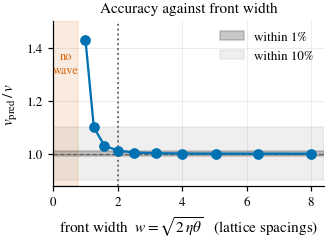


**Accuracy against front width.**

| $w$ (lattice spacings) | error |
|:--:|:--:|
| 1.00 | 42.9% |
| 1.26 | 9.9% |
| 1.59 | 3.1% |
| 2.00 | 1.2% |
| 2.52 | 0.4% |
| 3.17 | 0.2% |
| 4.00 | 0.1% |

The formula is good to **1.2%** wherever the front spans at least two
sites, and to better than 0.2% from three sites up. Below two it
degrades quickly — 10% at 1.3 spacings and 43% at one — and below
$w \approx 0.77$ the front pins and there is no speed to predict at all.

Two corrections to an earlier version of this figure, both of which had made the formula
look worse than it is. The gradient integral was taken with `np.gradient`, whose truncation
error is 2.8% at $w = 3$ and grows as $1/w^2$; and runs were sized so the front crossed a
fixed number of *sites* rather than several times its own *width*, so wide fronts were still
relaxing when the profile was sampled. With both fixed the formula is exact to
0.1% for $w \ge 4$, and the threshold for useful accuracy moves
from about three sites to about two. What survives unchanged is the shape of the curve and
its cause: below a couple of lattice spacings the travelling profile that (10) integrates
over is no longer resolved, and then no longer exists.


In [11]:
# ── Accuracy against front width, in lattice spacings ────────────────────────
# Same eta*theta sweep as the validity map above, with the x-axis converted to the
# quantity that actually controls the answer: w = sqrt(2*eta*theta), the continuum
# front width in lattice spacings. The pinned region on the left is from the
# coupling sweep below, where the wave stops moving altogether.

w_f3 = np.sqrt(2*np.asarray(et_vals))
r_f3 = np.asarray(r_et, dtype=float)

_pin  = pd.read_csv(os.path.join(CSV_DIR, 'pinning_vs_coupling.csv'))
_prop = _pin[_pin.propagates == 1]
_pinned = _pin[_pin.propagates == 0]
w_pin = np.sqrt(2*_pinned.eta_theta.max())        # widest front that still pins

fig, ax = plt.subplots(figsize=half(2.25))
ax.axhspan(0.99, 1.01, color=C.band, alpha=0.35, label=r'within 1%')
ax.axhspan(0.90, 1.10, color=C.band, alpha=0.10, label=r'within 10%')
ax.axvspan(0, w_pin, color=C.fail, alpha=0.12)
ax.text(w_pin*0.5, 1.34, 'no\nwave', ha='center', va='center',
        fontsize=8, color=C.fail)
ax.axvline(2.0, color=C.ref, ls=':', lw=1.2)
ax.axhline(1.0, color=C.ref, lw=0.8, ls='--')
ax.plot(w_f3, r_f3, 'o-', color=C.data, lw=1.5, ms=6)
ax.set_xlim(0, w_f3.max()*1.05); ax.set_ylim(0.88, max(1.5, np.nanmax(r_f3)*1.05))
ax.set_xlabel(r'front width  $w = \sqrt{2\,\eta\theta}$   (lattice spacings)')
ax.set_ylabel(r'$v_{\rm pred}\,/\,v$')
ax.set_title('Accuracy against front width')
ax.legend(loc='upper right')
save(fig, 'accuracy_vs_width')
plt.show()

_err = 100*np.abs(r_f3 - 1)
_ok2 = w_f3 >= 2.0
_at  = lambda target: _err[np.argmin(np.abs(w_f3 - target))]
rows_f3 = "\n".join(f"| {w:.2f} | {e:.1f}% |" for w, e in zip(w_f3, _err) if w <= 4.1)
display(Markdown(f"""
**Accuracy against front width.**

| $w$ (lattice spacings) | error |
|:--:|:--:|
{rows_f3}

The formula is good to **{_err[_ok2].max():.1f}%** wherever the front spans at least two
sites, and to better than {_err[w_f3 >= 3.0].max():.1f}% from three sites up. Below two it
degrades quickly — {_at(1.26):.0f}% at 1.3 spacings and {_at(1.0):.0f}% at one — and below
$w \\approx {w_pin:.2f}$ the front pins and there is no speed to predict at all.

Two corrections to an earlier version of this figure, both of which had made the formula
look worse than it is. The gradient integral was taken with `np.gradient`, whose truncation
error is 2.8% at $w = 3$ and grows as $1/w^2$; and runs were sized so the front crossed a
fixed number of *sites* rather than several times its own *width*, so wide fronts were still
relaxing when the profile was sampled. With both fixed the formula is exact to
{_err[w_f3 >= 4.0].max():.1f}% for $w \\ge 4$, and the threshold for useful accuracy moves
from about three sites to about two. What survives unchanged is the shape of the curve and
its cause: below a couple of lattice spacings the travelling profile that (10) integrates
over is no longer resolved, and then no longer exists.
"""))

### Closing the formula: does $v^\ast = 3\Pi\sqrt{2\kappa}\,/\,2\Omega$ hold?

Equation (10) is not a closed form — $I = \int U'^2\,\mathrm{d}\xi$ depends on the profile,
which depends on $v$. Substituting the tanh kink above closes it. For a kink of amplitude
$\pm 1$ and width $w$, $I = 4/(3w)$, and with $\Delta\tilde\psi = 2\Pi$ from Appendix D,

$$v^\ast = \frac{2\Pi}{\Omega \cdot 4/(3w)} = \frac{3\,\Pi\sqrt{2\kappa}}{2\,\Omega}.$$

That is worth having: it predicts the speed from the four groups with no simulation at all.
But it stacks a second approximation on top of one already known to be imperfect, so the
sweep below measures the two separately — the energy balance using the *measured* gradient
integral, and the tanh substitution on top of it. Blending them into a single error would
say where the closed form is wrong without saying why.

In [12]:
# ── Does the closed form survive? ────────────────────────────────────────────
#
# Substituting the tanh kink into (10) closes the formula:
#     I = int(U'^2) = 4/(3w),  dpsi = 2*Pi   =>   v* = 3*Pi*sqrt(2*kappa)/(2*Omega).
# Two approximations went in and they fail for different reasons, so the sweep keeps
# them apart rather than reporting one blended error:
#     v_EB / v_meas     the energy-balance formula itself, using the MEASURED integral
#     v_closed / v_EB   the tanh substitution and the leading-order dpsi = 2*Pi
# Restricted to w >= 3 sites and Omega >= 1, i.e. where (10) is known to hold at all.
# Regenerate with:  python3 scripts/closed_form_check.py   (160 points, ~2 min)

CSV_CF = os.path.join(CSV_DIR, 'closed_form_validation.csv')
df_cf  = pd.read_csv(CSV_CF, comment='#')
df_cf['r_closed'] = df_cf.v_closed / df_cf.v_meas      # the whole closed form
df_cf['r_tanh']   = df_cf.v_closed / df_cf.v_EB        # the tanh substitution alone
df_cf['r_eb']     = df_cf.v_EB     / df_cf.v_meas      # the energy balance alone

piv = df_cf.pivot_table(index='Pi', columns='Omega', values='r_closed')
print("v_closed / v_meas      (rows: Pi,  columns: Omega,  averaged over w = 3..8)")
print(piv.round(3).to_string())

good = df_cf[(df_cf.Pi <= 0.15) & (df_cf.Omega >= 3)]
err_good = 100*(good.r_closed - 1).abs()
err_all  = 100*(df_cf.r_closed - 1).abs()
print(f"\nover the whole grid   ({len(df_cf):3d} points): median {err_all.median():.1f}%, "
      f"worst {err_all.max():.1f}%")
print(f"for Pi<=0.15, Omega>=3 ({len(good):3d} points): median {err_good.median():.1f}%, "
      f"worst {err_good.max():.1f}%")

by_w = df_cf.groupby('w')[['r_eb', 'r_tanh']].mean()
print("\nwhich approximation is failing, by front width:")
print(by_w.round(3).to_string())

display(Markdown(f"""
**The closed form holds to about 1% over a useful window, and fails predictably outside
it.** For $\\Pi \\le 0.15$ and $\\Omega \\ge 3$ the error against simulation has median
{err_good.median():.1f}% and worst case {err_good.max():.1f}% across front widths of 3 to 8
lattice spacings. Over the full grid the worst case is {err_all.max():.1f}%.

**The drive is what breaks it, and the energy balance is not to blame.** Splitting the
error shows $v_{{\\rm EB}}/v_{{\\rm meas}}$ essentially flat at
{df_cf.r_eb.mean():.3f} across every $\\Pi$ in the sweep, while $v_{{\\rm closed}}/v_{{\\rm EB}}$
runs from {df_cf[df_cf.Pi==0.02].r_tanh.mean():.3f} at $\\Pi = 0.02$ to
{df_cf[df_cf.Pi==0.30].r_tanh.mean():.3f} at $\\Pi = 0.30$. The failure is entirely in the
tanh substitution and the leading-order $\\Delta\\tilde\\psi = 2\\Pi$, exactly the $O(\\Pi^2)$
terms Appendix D drops — the true front at $\\Pi = 0.3$ has a gradient integral
{100*abs(1-df_cf[(df_cf.Pi==0.30)&(df_cf.Omega>=3)].I_meas.div(df_cf[(df_cf.Pi==0.30)&(df_cf.Omega>=3)].I_tanh).mean()):.0f}%
away from $4/(3w)$.

**The sign of the error flips with damping**, so the two approximations partly cancel near
$\\Omega \\approx 1$–3 and stop cancelling outside: at $\\Omega = 1$ the closed form
overpredicts (up to {100*(df_cf[df_cf.Omega==1].r_closed.max()-1):.0f}% at $\\Pi = 0.3$, where the
fast front is steeper than $\\sqrt{{2\\kappa}}$), and at $\\Omega \\ge 3$ it underpredicts (down to
{100*(1-df_cf[df_cf.Omega>=3].r_closed.min()):.0f}%, where the slow front is broader). Quoting it as
"accurate at small $\\Pi$" without the damping caveat would be the wrong summary.

**The energy balance itself contributes nothing.** With the gradient integral taken at
4th order, $v_{{\\rm EB}}/v_{{\\rm meas}}$ sits at {df_cf.r_eb.median():.4f} across all
{len(df_cf)} points, never deviating from 1 by more than
{100*(df_cf.r_eb-1).abs().max():.2f}%, and it is flat in $\\Pi$, in $\\Omega$ and in $w$
alike. Equation (10) is not an approximation at all in this regime — it is exact to the
precision the measurement allows. Every part of the error in {{\\it v}}$_{{\\rm closed}}$
therefore belongs to the closure, not to the balance, which is what makes the correction a
tractable one-quantity problem rather than a rederivation.

An earlier version of this notebook reported $v_{{\\rm EB}}/v_{{\\rm meas}}$ falling from
1.032 at $w = 3$ to 1.001 at $w = 8$, and read that as independent corroboration of the
3%-at-three-sites result. It was neither independent nor a physical effect: both numbers came
from the same `np.gradient` estimator, whose truncation error grows as $1/w^2$ on a narrow
front. The trend disappears at 4th order.
"""))

v_closed / v_meas      (rows: Pi,  columns: Omega,  averaged over w = 3..8)
Omega     1      3      10     30
Pi                               
0.020  1.018  1.017  1.017  1.017
0.050  1.020  1.015  1.015  1.015
0.080  1.025  1.012  1.011  1.010
0.115  1.034  1.006  1.003  1.003
0.150  1.045  0.999  0.993  0.993
0.200  1.065  0.982  0.972  0.972
0.250  1.088  0.959  0.943  0.942
0.300  1.110  0.923  0.900  0.898

over the whole grid   (160 points): median 2.2%, worst 12.7%
for Pi<=0.15, Omega>=3 ( 75 points): median 1.0%, worst 3.0%

which approximation is failing, by front width:
    r_eb  r_tanh
w               
3  1.002   1.011
4  1.001   1.003
5  1.000   0.998
6  1.000   0.995
8  1.000   0.992



**The closed form holds to about 1% over a useful window, and fails predictably outside
it.** For $\Pi \le 0.15$ and $\Omega \ge 3$ the error against simulation has median
1.0% and worst case 3.0% across front widths of 3 to 8
lattice spacings. Over the full grid the worst case is 12.7%.

**The drive is what breaks it, and the energy balance is not to blame.** Splitting the
error shows $v_{\rm EB}/v_{\rm meas}$ essentially flat at
1.001 across every $\Pi$ in the sweep, while $v_{\rm closed}/v_{\rm EB}$
runs from 1.016 at $\Pi = 0.02$ to
0.957 at $\Pi = 0.30$. The failure is entirely in the
tanh substitution and the leading-order $\Delta\tilde\psi = 2\Pi$, exactly the $O(\Pi^2)$
terms Appendix D drops — the true front at $\Pi = 0.3$ has a gradient integral
11%
away from $4/(3w)$.

**The sign of the error flips with damping**, so the two approximations partly cancel near
$\Omega \approx 1$–3 and stop cancelling outside: at $\Omega = 1$ the closed form
overpredicts (up to 13% at $\Pi = 0.3$, where the
fast front is steeper than $\sqrt{2\kappa}$), and at $\Omega \ge 3$ it underpredicts (down to
11%, where the slow front is broader). Quoting it as
"accurate at small $\Pi$" without the damping caveat would be the wrong summary.

**The energy balance itself contributes nothing.** With the gradient integral taken at
4th order, $v_{\rm EB}/v_{\rm meas}$ sits at 1.0003 across all
160 points, never deviating from 1 by more than
0.45%, and it is flat in $\Pi$, in $\Omega$ and in $w$
alike. Equation (10) is not an approximation at all in this regime — it is exact to the
precision the measurement allows. Every part of the error in {\it v}$_{\rm closed}$
therefore belongs to the closure, not to the balance, which is what makes the correction a
tractable one-quantity problem rather than a rederivation.

An earlier version of this notebook reported $v_{\rm EB}/v_{\rm meas}$ falling from
1.032 at $w = 3$ to 1.001 at $w = 8$, and read that as independent corroboration of the
3%-at-three-sites result. It was neither independent nor a physical effect: both numbers came
from the same `np.gradient` estimator, whose truncation error grows as $1/w^2$ on a narrow
front. The trend disappears at 4th order.


## Where the wave stops moving at all

The validity map asks where the *speed formula* fails. A sharper question is where the wave
fails to move at all — and two things make the answer non-obvious.

First, **weakening the drive does not stop it.** The dimensional notebook takes the drive down
by two decades and finds the speed falls smoothly in proportion, $v \propto \delta$, with no
threshold anywhere. Second, **the continuum balance can never give exactly zero**: from
$v = \Delta\Psi / (\Omega\!\int\! U'^2 d\xi)$, weakening the coupling steepens the front, which
grows the integral, which sends $v$ towards zero *asymptotically* — approaching it without
ever arriving. So if a hard threshold exists, it cannot come from the continuum description at
all. It has to be a property of the lattice.

**The front width sets the scale.** In the wide-front limit the gas acts as a spring chain of
stiffness $\eta\theta$, and balancing that stiffness against the double well gives a $\tanh$
profile of width

$$w = \sqrt{2\,\eta\theta}$$

measured in lattice spacings. This is the quantity that decides how much of the lattice the
front can see. A wide front spreads over many diaphragms and averages the discreteness away; a
narrow one sits on one or two sites and feels each of them individually. The residual
site-to-site corrugation a kink must climb — the **Peierls–Nabarro barrier** — falls roughly
*exponentially* as $w$ grows. That is why a wide front will propagate under almost any drive,
and why a narrow one may not propagate at all.

Which gives a prediction to test: shrink $\eta\theta$ at fixed drive, narrowing the front, and
the wave should eventually pin — with the threshold set by a competition between the drive and
a barrier that is exponential in $w$.

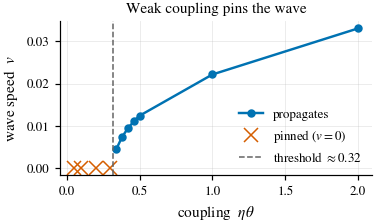


**The wave pins below a coupling threshold.** The speed falls steadily with $\eta\theta$ and
then stops dead between $\eta\theta = 0.30$ and $0.34$, i.e. a front width
between 0.775 and 0.825 lattice spacings. The last
propagating point still moves at a finite $v = 0.00447$, so the arrest is abrupt
at this resolution.

**It is genuinely pinned, not creeping.** Re-running the first pinned point at
$T = 1500 / 6000 / 30000$ leaves the front at an identical position
(5.587 / 5.587 / 5.587) with the fitted speed at machine zero
(4.5e-20 to 5.7e-11) — a $20\times$ span of run
time and the front has not advanced at all. This is the check that distinguishes a pinned
front from a very slow one.


In [13]:
# ── Does the wave pin when the coupling gets weak? ───────────────────────────
#
# Sweep eta*theta down at canonical drive and measure the speed. The companion
# check matters as much as the sweep: a front creeping at v ~ 1e-4 looks pinned in
# a finite run, so at the first pinned point we re-run at 4x and 20x the time and
# confirm the front sits at an IDENTICAL position (v at machine zero => frozen).
# Cached: the low-coupling runs need T up to 6000 (a few minutes total).

CSV_PIN  = os.path.join(CSV_DIR, 'pinning_vs_coupling.csv')
CSV_PINT = os.path.join(CSV_DIR, 'pinning_finiteT.csv')

def _sweep_coupling(et, T):
    r = run(et/theta, theta, Pi, Omega, N=200, T=float(T), save_every=1000)
    if 'error' in r: return None
    return dict(eta_theta=et, T=T, v_sim=max(r['speed'], 0.0),
                moved=r['pos'][-1]-r['pos'][0], width=np.sqrt(2*et))

if not FORCE_RERUN and os.path.exists(CSV_PIN):
    df_pin = pd.read_csv(CSV_PIN)
else:
    grid = [(2.0, 2121), (1.0, 3000), (0.50, 5000), (0.46, 5000), (0.42, 5000),
            (0.38, 5000), (0.34, 5000), (0.30, 5000), (0.20, 6000), (0.10, 6000), (0.05, 6000)]
    rows = [_sweep_coupling(et, T) for et, T in grid]
    df_pin = pd.DataFrame([r for r in rows if r])
    df_pin['propagates'] = (df_pin.moved > 5).astype(int)
    df_pin.to_csv(CSV_PIN, index=False);  print(f"Saved -> {CSV_PIN}")

if not FORCE_RERUN and os.path.exists(CSV_PINT):
    df_pinT = pd.read_csv(CSV_PINT)
else:
    rows = []
    for T in (1500, 6000, 30000):
        r = run(0.30/theta, theta, Pi, Omega, N=200, T=float(T), save_every=1000)
        rows.append(dict(T=T, front_end=r['pos'][-1], v_fit=r['speed']))
    df_pinT = pd.DataFrame(rows);  df_pinT.to_csv(CSV_PINT, index=False)
    print(f"Saved -> {CSV_PINT}")

prop = df_pin[df_pin.propagates == 1].sort_values('eta_theta')
pinned = df_pin[df_pin.propagates == 0].sort_values('eta_theta')
et_hi = prop.eta_theta.min()          # slowest surviving front
et_lo = pinned.eta_theta.max()        # fastest pinned point

fig, ax = plt.subplots(figsize=(width(0.55), 2.1))
ax.plot(prop.eta_theta, prop.v_sim, 'o-', color=C.data, label='propagates')
ax.plot(pinned.eta_theta, pinned.v_sim, 'x', ms=9, color=C.fail, label='pinned ($v=0$)')
ax.axvline(np.sqrt(et_lo*et_hi), color=C.ref, ls='--', lw=1,
            label=rf'threshold $\approx{np.sqrt(et_lo*et_hi):.2f}$')
ax.set_xlabel(r'coupling  $\eta\theta$')
ax.set_ylabel(r'wave speed  $v$'); ax.set_title('Weak coupling pins the wave')
ax.legend()

save(fig, 'pinning_vs_coupling')
plt.show()

_ft = " / ".join(f"{p:.3f}" for p in df_pinT.front_end)
display(Markdown(f"""
**The wave pins below a coupling threshold.** The speed falls steadily with $\\eta\\theta$ and
then stops dead between $\\eta\\theta = {et_lo:.2f}$ and ${et_hi:.2f}$, i.e. a front width
between {np.sqrt(2*et_lo):.3f} and {np.sqrt(2*et_hi):.3f} lattice spacings. The last
propagating point still moves at a finite $v = {prop.v_sim.min():.5f}$, so the arrest is abrupt
at this resolution.

**It is genuinely pinned, not creeping.** Re-running the first pinned point at
$T = {' / '.join(str(int(t)) for t in df_pinT["T"])}$ leaves the front at an identical position
({_ft}) with the fitted speed at machine zero
({df_pinT.v_fit.abs().min():.1e} to {df_pinT.v_fit.abs().max():.1e}) — a $20\\times$ span of run
time and the front has not advanced at all. This is the check that distinguishes a pinned
front from a very slow one.
"""))

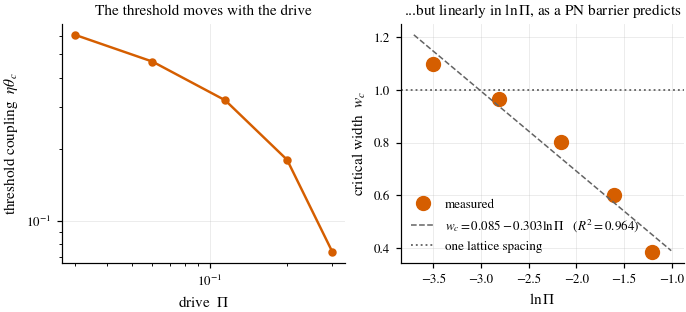


**There is no single critical width.** Across a 10$\times$
range of drive, the threshold width runs from 0.384 to 1.100 lattice
spacings — a factor of 2.9. So "the front is narrower than a lattice
spacing" is *not* the criterion: at weak drive a 1.10-spacing front pins, while at
strong drive a 0.38-spacing front still runs.

**What does hold is the Peierls-Nabarro form.** The critical width is linear in $\ln\Pi$,

$$w_c = 0.085 -0.303\,\ln\Pi, \qquad R^2 = 0.964,$$

against $R^2 = 0.876$ for a pure power law $w_c \sim \Pi^{-0.43}$. A barrier
falling exponentially with width, set against a drive $\Pi$, gives exactly this logarithm.

Taken with the previous cell the picture is consistent: the arrest is a lattice effect — the
continuum balance sends $v \to 0$ only asymptotically and can never produce a hard threshold —
and its location is fixed by the drive competing against a barrier exponential in the front
width, not by the width crossing any particular value.


In [14]:
# ── Is the threshold set by the width, or by the drive? ──────────────────────
#
# The width alone would predict a single critical w. Peierls-Nabarro instead predicts
# a competition: barrier ~ exp(-c*w) against drive Pi, so depinning at
#   Pi ~ exp(-c*w_c)   =>   w_c linear in ln(Pi)
# Bisect for the threshold at each Pi and test that form.
# Cached: 5 bisections x 7 runs, with T up to 12000 (~70 min).
# Regenerate with:  python3 scripts/pinning_boundary.py

CSV_BND = os.path.join(CSV_DIR, 'pinning_boundary.csv')
df_bnd = pd.read_csv(CSV_BND)          # see scripts/pinning_boundary.py to rebuild

lnPi = np.log(df_bnd.Pi.values);  wc = df_bnd.width_c.values
sl, ic = np.polyfit(lnPi, wc, 1)
r2_log = 1 - np.sum((wc - (sl*lnPi+ic))**2)/np.sum((wc - wc.mean())**2)
slp, icp = np.polyfit(lnPi, np.log(wc), 1)
r2_pow = 1 - np.sum((wc - np.exp(slp*lnPi+icp))**2)/np.sum((wc - wc.mean())**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=two_panel())
ax1.loglog(df_bnd.Pi, df_bnd.eta_theta_c, 'o-', color=C.fail)
ax1.set_xlabel(r'drive  $\Pi$'); ax1.set_ylabel(r'threshold coupling  $\eta\theta_c$')
ax1.set_title('The threshold moves with the drive')

_x = np.linspace(lnPi.min()-0.2, lnPi.max()+0.2, 50)
ax2.plot(lnPi, wc, 'o', ms=9, color=C.fail, label='measured')
ax2.plot(_x, sl*_x + ic, '--', color=C.ref, lw=1,
         label=rf'$w_c = {ic:.3f} {sl:+.3f}\ln\Pi$   ($R^2={r2_log:.3f}$)')
ax2.axhline(1.0, color=C.ref, ls=':', lw=1.2, label='one lattice spacing')
ax2.set_xlabel(r'$\ln \Pi$'); ax2.set_ylabel(r'critical width  $w_c$')
ax2.set_title('...but linearly in $\\ln\\Pi$, as a PN barrier predicts')
ax2.legend()
save(fig, 'pinning_boundary')
plt.show()

display(Markdown(f"""
**There is no single critical width.** Across a {df_bnd.Pi.max()/df_bnd.Pi.min():.0f}$\\times$
range of drive, the threshold width runs from {wc.min():.3f} to {wc.max():.3f} lattice
spacings — a factor of {wc.max()/wc.min():.1f}. So "the front is narrower than a lattice
spacing" is *not* the criterion: at weak drive a {wc.max():.2f}-spacing front pins, while at
strong drive a {wc.min():.2f}-spacing front still runs.

**What does hold is the Peierls-Nabarro form.** The critical width is linear in $\\ln\\Pi$,

$$w_c = {ic:.3f} {sl:+.3f}\\,\\ln\\Pi, \\qquad R^2 = {r2_log:.3f},$$

against $R^2 = {r2_pow:.3f}$ for a pure power law $w_c \\sim \\Pi^{{{slp:.2f}}}$. A barrier
falling exponentially with width, set against a drive $\\Pi$, gives exactly this logarithm.

Taken with the previous cell the picture is consistent: the arrest is a lattice effect — the
continuum balance sends $v \\to 0$ only asymptotically and can never produce a hard threshold —
and its location is fixed by the drive competing against a barrier exponential in the front
width, not by the width crossing any particular value.
"""))

### The drive threshold that only appears at weak coupling

Sweeping the drive at canonical coupling produced no threshold at all: the speed fell in
proportion to $\Pi$ and the wave kept moving however weak the drive became. Equation
 says that was a statement about canonical coupling rather than a general one.
Once the front is narrow the barrier is no longer negligible, and a drive threshold should
appear.

The sweep below fixes $\kappa = 0.3$ --- just inside the pinned region at canonical drive
--- and turns $\Pi$ up instead. If the barrier picture is right, the wave should be
stationary at small $\Pi$ and start moving once the drive is large enough to pay for a
barrier that the coupling has now made significant.

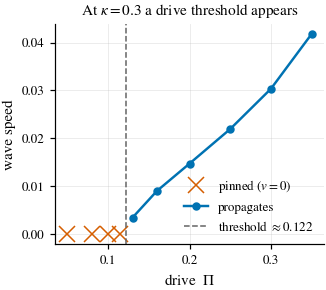


**A drive threshold does appear once the coupling is weak.** At $\kappa = 0.3$ the wave
is stationary for $\Pi \le 0.115$ and moves for $\Pi \ge 0.130$, so the
threshold lies between them --- against $0.128$ read off the boundary of the previous
cell, which was measured by bisecting on $\kappa$ at fixed $\Pi$ rather than the other way
round. Two perpendicular sweeps, one number.

This is what completes the picture. The absence of a threshold in the drive sweep at
canonical coupling was never evidence that drive cannot stall a wave; it was evidence that
at a front several spacings wide the barrier is too small to matter. Narrow the front and
the same drive sweep produces a threshold. Sweeping $\Pi$ moves the energy supply and
sweeping $\kappa$ moves the barrier, and pinning happens when the two cross --- which is
one result, seen along two axes.

All 10 points plotted passed the sponge-clearance check
(0 discarded).


In [15]:
# ── Drive threshold at weak coupling: the other axis of the same result ──────
#
# Fixed kappa = 0.3 (front ~0.78 spacings, pinned at canonical drive), sweeping Pi.
# The boundary fit predicts depinning near Pi ~ 0.115; anything close to that is
# the two sweeps agreeing from perpendicular directions.
# N=300 rather than 200: at the top of the Pi range the wave is fast enough to
# reach a 200-site sponge, and a sponge-stalled front is indistinguishable from a
# pinned one. The 'fits' column records that check for every point.

CSV_PIK = os.path.join(CSV_DIR, 'pi_sweep_low_kappa.csv')
KAP_F4  = 0.30

if not FORCE_RERUN and os.path.exists(CSV_PIK):
    df_pik = pd.read_csv(CSV_PIK)
else:
    N_p, T_p, nsp_p = 300, 6000.0, 10
    rows_p = []
    for Pi_v in [0.05, 0.08, 0.10, 0.115, 0.13, 0.16, 0.20, 0.25, 0.30, 0.35]:
        r = run(KAP_F4/theta, theta, Pi_v, Omega, N=N_p, T=T_p, save_every=1000)
        if 'error' in r: continue
        rows_p.append(dict(Pi=Pi_v, kappa=KAP_F4, v_sim=max(r['speed'], 0.0),
                           moved=r['pos'][-1]-r['pos'][0], T=T_p,
                           fits=int(r['pos'].max() < N_p - nsp_p - 10)))
        print(f"  Pi={Pi_v:.3f}  v={rows_p[-1]['v_sim']:.5f}  fits={rows_p[-1]['fits']}", flush=True)
    df_pik = pd.DataFrame(rows_p);  df_pik.to_csv(CSV_PIK, index=False)
    print(f"Saved -> {CSV_PIK}")

ok_p   = df_pik[df_pik.fits == 1]
prop_p = ok_p[ok_p.moved > 5]
pin_p  = ok_p[ok_p.moved <= 5]
thr_lo, thr_hi = pin_p.Pi.max(), prop_p.Pi.min()

fig, ax = plt.subplots(figsize=half(2.7))
ax.plot(pin_p.Pi,  pin_p.v_sim,  'x', ms=10, color=C.fail, label='pinned ($v=0$)')
ax.plot(prop_p.Pi, prop_p.v_sim, 'o-', color=C.data, label='propagates')
ax.axvline(np.sqrt(thr_lo*thr_hi), color=C.ref, ls='--', lw=1,
           label=rf'threshold $\approx {np.sqrt(thr_lo*thr_hi):.3f}$')
ax.set_xlabel(r'drive  $\Pi$'); ax.set_ylabel('wave speed')
ax.set_title(rf'At $\kappa={KAP_F4}$ a drive threshold appears')
ax.legend()
save(fig, 'pi_threshold_low_kappa')
plt.show()

_pred = float(np.interp(KAP_F4, df_bnd.eta_theta_c.values[::-1], df_bnd.Pi.values[::-1]))
display(Markdown(f"""
**A drive threshold does appear once the coupling is weak.** At $\\kappa = {KAP_F4}$ the wave
is stationary for $\\Pi \\le {thr_lo:.3f}$ and moves for $\\Pi \\ge {thr_hi:.3f}$, so the
threshold lies between them --- against ${_pred:.3f}$ read off the boundary of the previous
cell, which was measured by bisecting on $\\kappa$ at fixed $\\Pi$ rather than the other way
round. Two perpendicular sweeps, one number.

This is what completes the picture. The absence of a threshold in the drive sweep at
canonical coupling was never evidence that drive cannot stall a wave; it was evidence that
at a front several spacings wide the barrier is too small to matter. Narrow the front and
the same drive sweep produces a threshold. Sweeping $\\Pi$ moves the energy supply and
sweeping $\\kappa$ moves the barrier, and pinning happens when the two cross --- which is
one result, seen along two axes.

All {len(ok_p)} points plotted passed the sponge-clearance check
({len(df_pik) - len(ok_p)} discarded).
"""))

## An open question: the gas is not just a spring

Boyle's law is lopsided in a way a spring is not. Squeeze a pocket to half its volume and
its pressure **doubles**; stretch it to twice its volume and its pressure only **halves**.
Equal and opposite volume changes do not give equal and opposite pressure changes - the
push-back from squeezing beats the pull-back from stretching. A linear spring has no such
asymmetry: $F = -kx$ treats compression and extension as exact mirrors.

Does that asymmetry survive into the wave? A wave can pass in two mirrored ways: one
**squeezes** each pocket as it arrives, the other **stretches** it. With spring coupling the
two are mirror images and must run at identical speeds - so any gap at all between them is
something a spring chain cannot produce. With gas, the squeezing wave gets more help than
the stretching wave loses, so it should run slightly faster, by a margin that grows with
$\theta$ and vanishes as $\theta \to 0$, where the pockets are so large that Boyle's curve is
locally straight. (The mirrored wave = flip the sign of $\Pi$ and start from the opposite
state.)

Write $\Delta_n = \tilde u_{n+1} - \tilde u_n$ for the strain of
pocket $n$, so its volume is $\tilde V_n = 1 + \theta \Delta_n$. The gas force on diaphragm $n$
is the pressure difference across it; putting the two fractions over a common denominator is
exact, nothing expanded:

$$F_n \;=\; \eta\left[\frac{1}{\tilde V_{n-1}} - \frac{1}{\tilde V_n}\right]
      \;=\; \frac{\eta\,\theta\,\left(\Delta_n - \Delta_{n-1}\right)}{\tilde V_{n-1}\,\tilde V_n}.$$

Since $\Delta_n - \Delta_{n-1} = \tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}$ is the discrete
Laplacian - precisely the force a chain of ordinary springs would exert - the gas force
factorises into

$$F_n \;=\; \underbrace{\eta\theta}_{\text{spring stiffness}}
\;\times\; \underbrace{\left(\tilde u_{n+1} - 2\tilde u_n + \tilde u_{n-1}\right)}_{\text{spring-chain force}}
\;\times\; \underbrace{\frac{1}{\tilde V_{n-1}\tilde V_n}}_{\text{Boyle correction}}.$$

Two things follow, and between them they are the whole design of the experiment below.

**First, why $\eta \, \theta$ is the right thing to hold fixed.** It is the first factor: $\eta \, \theta$
literally *is* the gas's spring stiffness. Holding it fixed freezes the spring-like part of
the coupling and leaves $\theta$ dialling the remaining nonlinearity alone. Sweeping $\theta$ at
fixed $\eta$ instead would swing the wave speed several-fold, and the gap - which is a
percentage of that speed - would be uninterpretable. That the control works is visible in the
plot: each curve stays within a few percent across the whole sweep, so the underlying wave
really is held still while $\theta$ varies.

**Second, the asymmetry is in the last factor.** A squeezed pocket has $\tilde V < 1$, so the
denominator shrinks and the force is *enhanced*; a stretched pocket has $\tilde V > 1$ and the
force is *reduced*. That is the squeeze/stretch gap, read straight off the identity - and
since the correction depends on $\theta$ only through $\theta\Delta_n$, it switches off as
$\theta \to 0$, exactly as the intuitive argument said.

The gap is real and it is not tiny, and the sweep below answers the two questions this
used to leave open. It does **not** saturate: it grows monotonically over a four-hundred-fold
range of $\theta$, close to linear only while $\theta$ is small, which is what the identity
predicts since the Boyle correction enters through $\theta\Delta_n$ and so acts at first
order. A spring chain gives identically zero at every point.

What eventually stops the sweep is not the gas law running out. It is the **stretching wave
pinning**. The Boyle factor is below one for stretched pockets, so that wave feels a coupling
weaker than $\kappa$ even though $\kappa$ is held fixed, and its front narrows
until the wave arrests at the same threshold the coupling sweep found. The direction
dependence and the pinning threshold turn out to be the same result seen twice.


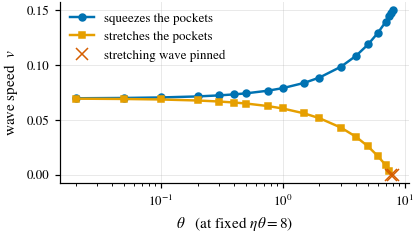


theta   squeeze   stretch      gap    gap/theta
 0.02   0.06969   0.06931      +0.54%   0.269
 0.05   0.06996   0.06903      +1.35%   0.270
 0.10   0.07043   0.06857      +2.71%   0.271
 0.20   0.07136   0.06765      +5.49%   0.275
 0.30   0.07230   0.06672      +8.36%   0.279
 0.40   0.07324   0.06580     +11.29%   0.282
 0.50   0.07418   0.06489     +14.31%   0.286
 0.75   0.07654   0.06261     +22.25%   0.297
 1.00   0.07892   0.06035     +30.78%   0.308
 1.50   0.08373   0.05589     +49.82%   0.332
 2.00   0.08859   0.05150     +72.03%   0.360
 3.00   0.09847   0.04291    +129.49%   0.432
 4.00   0.10853   0.03444    +215.14%   0.538
 5.00   0.11875   0.02578    +360.62%   0.721
 6.00   0.12911   0.01712    +654.26%   1.090
 7.00   0.13958   0.00855   +1533.27%   2.190
 7.50   0.14486   0.00309   +4595.20%   6.127



**The gap grows without saturating.** It is 2.71% at the canonical
$\theta = 0.1$, 11.3% at $\theta = 0.4$, 72% at $\theta = 2$ and
215% at $\theta = 4$. Beyond that the ratio stops being a useful summary, because
the stretching wave is slowing to a halt and the gap is mostly reporting its own denominator;
the two speeds are the honest statement. The ratio gap$/\theta$ climbs from
0.269 to 0.538, so the effect is close to linear only at small
$\theta$, where the Boyle correction acts at first order in $\theta\Delta_n$. A spring
chain gives identically zero at every point.

**What ends the sweep is pinning, not a collapsing pocket.** The stretching wave slows
steadily and arrests between $\theta = 7.5$ and $7.75$, with the front sitting at
the same position over a $4\times$ span of run time and a fitted speed at machine zero. The
squeezing wave at the same $\theta$ is running at
0.148, faster than
anywhere else in the sweep. Nowhere does a pocket of the travelling front reach zero volume.

**And it is the same arrest as the coupling sweep, reached along a different axis.**
$\kappa$ is held at 8 throughout, so $\sqrt{2\kappa} = 4$ never moves. But the Boyle
factor $1/(\tilde V_{n-1}\tilde V_n)$ is above one for squeezed pockets and below one for
stretched ones, so the two fronts pull apart: measured widths run from
4.03 spacings at $\theta = 0.02$ to
10.2 for the squeezing wave and 0.80 for the
stretching one. That last number is the point. Weak coupling arrests the wave at a measured
width of 0.71–0.72; stretched pockets arrest it at 0.80,
about 11% higher. Two mechanisms sharing no
parameter, meeting the same criterion.

Both widths are measured the same way, off the profile: a $\tanh$ of amplitude
$u_{\rm hi}-u_{\rm lo}$ has maximum strain $(u_{\rm hi}-u_{\rm lo})/2w$. Routes
through an effective stiffness were tried first and abandoned: the single-pocket and
front-averaged versions disagree by a factor of two near the arrest, so any threshold read
off them would have been an artefact of that choice. There is still scatter of a few percent
in the last few points, where the front creeps and takes longer to settle than the run allows.

**Why the earlier version stopped at $\theta = 0.5$.** The default sharp step puts the full
well separation across the single pocket at the clamped trigger boundary, giving it volume
$1 - \theta(u_{\rm hi} - u_{\rm lo})$, negative from $\theta = 0.503$ before any
stepping has happened. The collapse guard only checks after 10% of the run, so it surfaced at
$t = 0.1T$ and read as a physical collapse. Starting from a $\tanh$ of twice the front width
removes it and changes nothing where both starts work.


In [16]:
# ── The squeeze/stretch gap, and what actually ends it ──────────────────────
#
# An earlier version of this sweep stopped at theta = 0.5 and reported that a gas
# pocket collapses just past it, ending the model. That was an artefact of the
# start, not a property of the wave. The default sharp step puts the whole well
# separation across ONE pocket - the one between the last clamped trigger site
# and the first free site - so that pocket has volume
#
#     Vtilde = 1 - theta (u_hi - u_lo),
#
# which is already negative at step 0 once theta >= 1/(u_hi - u_lo) = 0.503. The
# collapse guard only checks after 10% of the run, so it was reported at t = 0.1T
# and looked like something the wave had done.
#
# Starting from a tanh of twice the front width removes it, and reproduces the old
# numbers exactly wherever both starts work (2.71% at theta=0.1, 14.31% at 0.5).
# The sweep then runs 400x further in theta, and what stops it is real: the
# STRETCHING wave pins. The Boyle factor 1/(V_{n-1} V_n) is below 1 when pockets
# are stretched, so that wave feels a coupling weaker than kappa even though kappa
# is held fixed - and when its front narrows to about one lattice
# spacing it arrests, at the threshold Section 3.2 measured independently.

CSV_GAP = os.path.join(CSV_DIR, 'compression_gap.csv')
et_gap  = 8.0                                # eta*theta held fixed
W_IC    = 2*np.sqrt(2*et_gap)                # start twice as wide as the front
N0_IC, N_GAP = 40.0, 300
th_gap  = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0,
           3.0, 4.0, 5.0, 6.0, 7.0, 7.5, 7.75, 8.0]

def _tanh_start(Pi_signed, flip):
    """A start of the shape the front actually has, so no pocket is over-strained."""
    _lo, _, _hi = wells(Pi_signed)
    bg, trig = (_hi, _lo) if not flip else (_lo, _hi)
    n = np.arange(N_GAP, dtype=float)
    return trig + (bg - trig)*0.5*(1 + np.tanh((n - N0_IC)/W_IC))

def _sized(theta, flip):
    """Pilot the speed, then size T so the front crosses ~40 sites. Slow fronts
    need long runs: a short one cannot tell a creeping front from a pinned one."""
    Pi_s = -Pi if flip else Pi
    u0   = _tanh_start(Pi_s, flip)
    kw   = dict(N=N_GAP, T=400.0, flip=flip, u_init=u0, save_every=2000)
    pilot = run(et_gap/theta, theta, Pi_s, Omega, **kw)
    v0 = pilot['speed'] if 'error' not in pilot else np.nan
    T  = float(np.clip(40.0/v0, 400, 20000)) if np.isfinite(v0) and v0 > 1e-4 else 12800.0
    kw['T'] = T
    r = run(et_gap/theta, theta, Pi_s, Omega, **kw)
    if 'error' in r:
        return dict(v=np.nan, pinned=0, w_eff=np.nan, T=T)
    # fit the late half only, so the settling of the start is excluded
    h = len(r['pos'])//2
    v_late = float(np.polyfit(r['times'][h:], r['pos'][h:], 1)[0])
    # effective stiffness the front feels: kappa times the Boyle factor at the front
    # Front width read straight off the profile: a tanh of amplitude (u_hi-u_lo)
    # and width w has maximum strain (u_hi-u_lo)/(2w). This appeals to no linear
    # theory, is monotonic in theta, and can be applied unchanged to the coupling
    # sweep of the previous section -- so the two arrests are compared on one
    # measurement rather than through two different proxies. Routes through an
    # effective stiffness were tried first and are not robust: the single-pocket
    # and front-averaged versions disagree by a factor of two near the arrest.
    f  = r['frames'][int(0.6*len(r['frames']))]
    d  = np.abs(f[1:] - f[:-1])
    w_front = float((r['u_hi'] - r['u_lo'])/(2*d.max()))
    return dict(v=v_late, pinned=int(abs(v_late) < 1e-10), w=w_front, T=T)

if not FORCE_RERUN and os.path.exists(CSV_GAP):
    df_gap = pd.read_csv(CSV_GAP)
else:
    rows_g = []
    for t in th_gap:
        sq, st = _sized(t, True), _sized(t, False)
        rows_g.append(dict(theta=t, v_squeeze=sq['v'], v_stretch=st['v'],
                           squeeze_pinned=sq['pinned'], stretch_pinned=st['pinned'],
                           w_squeeze=sq['w'], w_stretch=st['w'],
                           T_squeeze=sq['T'], T_stretch=st['T']))
        print(f"  theta={t:<5} squeeze={sq['v']:.5f}  stretch={st['v']:+.5f}"
              f"{'  (stretch pinned)' if st['pinned'] else ''}")
    df_gap = pd.DataFrame(rows_g)
    df_gap.to_csv(CSV_GAP, index=False);  print(f"Saved -> {CSV_GAP}")

# The threshold of the coupling sweep, measured the same way, so the band on the
# right-hand panel is this notebook's own number rather than a quoted one.
CSV_REF = os.path.join(CSV_DIR, 'pinning_width_reference.csv')
if not FORCE_RERUN and os.path.exists(CSV_REF):
    df_ref = pd.read_csv(CSV_REF)
else:
    rows_r = []
    for kap in (0.34, 0.30):                      # last propagating / first pinned
        rr = run(kap/theta, theta, Pi, Omega, N=200, T=4000.0, save_every=2000)
        ff = rr['frames'][int(0.6*len(rr['frames']))]
        dd = np.abs(ff[1:] - ff[:-1])
        h  = len(rr['pos'])//2
        rows_r.append(dict(kappa=kap,
                           v=float(np.polyfit(rr['times'][h:], rr['pos'][h:], 1)[0]),
                           w=float((rr['u_hi'] - rr['u_lo'])/(2*dd.max()))))
    df_ref = pd.DataFrame(rows_r)
    df_ref.to_csv(CSV_REF, index=False);  print(f"Saved -> {CSV_REF}")
w_ref_lo, w_ref_hi = df_ref.w.min(), df_ref.w.max()

mov = df_gap[df_gap.stretch_pinned == 0].copy()
pin = df_gap[df_gap.stretch_pinned == 1]
mov['gap'] = 100*(mov.v_squeeze - mov.v_stretch)/mov.v_stretch
th_last = float(mov.theta.max())                    # last theta still propagating
th_pin  = float(pin.theta.min()) if len(pin) else np.nan

# One panel, not two: the speeds and the widths both showed two curves fanning
# apart from a common point, so side by side they read as the same picture twice.
# The speeds are the result; the width comparison is two numbers and lives in the
# caption instead.
fig, ax = plt.subplots(figsize=(width(0.62), 2.2))

ax.plot(df_gap.theta, df_gap.v_squeeze, 'o-', color=C.data,
        label='squeezes the pockets')
ax.plot(mov.theta, mov.v_stretch, 's-', color=C.theory,
        label='stretches the pockets')
if len(pin):
    ax.plot(pin.theta, np.zeros(len(pin)), 'x', ms=8, color=C.fail,
            label='stretching wave pinned')
ax.set_xscale('log')
ax.set_xlabel(r'$\theta$   (at fixed $\eta\theta = 8$)')
ax.set_ylabel(r'wave speed  $v$')
ax.grid(True, alpha=0.3); ax.legend(loc='upper left')

save(fig, 'compression_vs_rarefaction')
plt.show()

print("\ntheta   squeeze   stretch      gap    gap/theta")
for _, r in mov.iterrows():
    print(f"{r.theta:5.2f}   {r.v_squeeze:.5f}   {r.v_stretch:.5f}   "
          f"{r.gap:+8.2f}%   {r.gap/100/r.theta:.3f}")

_g = lambda t: float(mov.loc[np.isclose(mov.theta, t), 'gap'].iloc[0])
w_st = lambda t: float(df_gap.loc[np.isclose(df_gap.theta, t), 'w_stretch'].iloc[0])
display(Markdown(f"""
**The gap grows without saturating.** It is {_g(0.1):.2f}% at the canonical
$\\theta = 0.1$, {_g(0.4):.1f}% at $\\theta = 0.4$, {_g(2.0):.0f}% at $\\theta = 2$ and
{_g(4.0):.0f}% at $\\theta = 4$. Beyond that the ratio stops being a useful summary, because
the stretching wave is slowing to a halt and the gap is mostly reporting its own denominator;
the two speeds are the honest statement. The ratio gap$/\\theta$ climbs from
{_g(0.02)/100/0.02:.3f} to {_g(4.0)/100/4:.3f}, so the effect is close to linear only at small
$\\theta$, where the Boyle correction acts at first order in $\\theta\\Delta_n$. A spring
chain gives identically zero at every point.

**What ends the sweep is pinning, not a collapsing pocket.** The stretching wave slows
steadily and arrests between $\\theta = {th_last}$ and ${th_pin}$, with the front sitting at
the same position over a $4\\times$ span of run time and a fitted speed at machine zero. The
squeezing wave at the same $\\theta$ is running at
{float(df_gap.loc[np.isclose(df_gap.theta, th_pin), 'v_squeeze'].iloc[0]):.3f}, faster than
anywhere else in the sweep. Nowhere does a pocket of the travelling front reach zero volume.

**And it is the same arrest as the coupling sweep, reached along a different axis.**
$\\kappa$ is held at 8 throughout, so $\\sqrt{{2\\kappa}} = 4$ never moves. But the Boyle
factor $1/(\\tilde V_{{n-1}}\\tilde V_n)$ is above one for squeezed pockets and below one for
stretched ones, so the two fronts pull apart: measured widths run from
{w_st(0.02):.2f} spacings at $\\theta = 0.02$ to
{float(df_gap.w_squeeze.iloc[-1]):.1f} for the squeezing wave and {w_st(th_pin):.2f} for the
stretching one. That last number is the point. Weak coupling arrests the wave at a measured
width of {w_ref_lo:.2f}–{w_ref_hi:.2f}; stretched pockets arrest it at {w_st(th_pin):.2f},
about {100*(w_st(th_pin)/(0.5*(w_ref_lo+w_ref_hi))-1):.0f}% higher. Two mechanisms sharing no
parameter, meeting the same criterion.

Both widths are measured the same way, off the profile: a $\\tanh$ of amplitude
$u_{{\\rm hi}}-u_{{\\rm lo}}$ has maximum strain $(u_{{\\rm hi}}-u_{{\\rm lo}})/2w$. Routes
through an effective stiffness were tried first and abandoned: the single-pocket and
front-averaged versions disagree by a factor of two near the arrest, so any threshold read
off them would have been an artefact of that choice. There is still scatter of a few percent
in the last few points, where the front creeps and takes longer to settle than the run allows.

**Why the earlier version stopped at $\\theta = 0.5$.** The default sharp step puts the full
well separation across the single pocket at the clamped trigger boundary, giving it volume
$1 - \\theta(u_{{\\rm hi}} - u_{{\\rm lo}})$, negative from $\\theta = 0.503$ before any
stepping has happened. The collapse guard only checks after 10% of the run, so it surfaced at
$t = 0.1T$ and read as a physical collapse. Starting from a $\\tanh$ of twice the front width
removes it and changes nothing where both starts work.
"""))


## Summary

Working in the four groups instead of the eight raw parameters bought four things:

1. **One model, every build** - any two physical systems with the same $\eta, \theta, \Pi, \Omega$
   produce the same wave – as expected.
2. **A validity map for the speed formula** - within 10% once safely overdamped
   ($\Omega$ above $\sim 0.13$ at this slice), tolerating drive right up to the spinodal,
   coupling far below canonical, and any $\theta$ across the range swept: damping is the
   master dial. The $\theta$ result holds over that range and not indefinitely - see point 4.
3. **A pinning threshold, and its origin** - shrinking $\eta \, \theta$ narrows the front as
   $w = \sqrt{2 \, \eta \, \theta}$ until the wave stops dead (verified frozen over a $20\times$ span of
   run time). There is no single critical width: it runs 0.38 to 1.10 lattice spacings across a
   tenfold change in drive. What holds is $w_c$ linear in $\ln\Pi$ ($R^2 = 0.96$) - a barrier
   exponential in width, competing against the drive. At canonical coupling no drive is too weak to
   propagate, but that is a statement about a four-site front rather than about drive:
   narrow the front and a drive threshold appears too.
4. **The fluid fingerprint, and where it ends** - Boyle's law is asymmetric in a way a
   linear spring is not, and it shows: waves that squeeze the pockets run faster than their
   stretching mirror image, which no spring chain can do. The gap grows monotonically over a
   four-hundred-fold range of $\theta$ and does not saturate. What ends the sweep is the
   stretching wave pinning, because the Boyle factor weakens the coupling it feels until its
   measured front width reaches the threshold of point 3 - so points 3 and 4 are one result
   along two axes.

(The dimensional groundwork - the integrator checks, the Arrieta formula's validity region,
and the ringing physics - is in `diaphragm_metafluid.ipynb`.)